# Analisis Ekstraksi Fitur dan K-Means Clustering Data Polutan
## 1. Import Library, Upload, dan Membaca Data

Dilakukan persiapan analisis dengan mengimpor beberapa library Python yang digunakan. NumPy digunakan untuk perhitungan numerik, Pandas untuk membaca dan mengolah data, Matplotlib dan Seaborn untuk membuat visualisasi, sedangkan Scikit-learn digunakan untuk proses standardisasi, PCA, K-Means, dan perhitungan Silhouette Score.

Selanjutnya, program meminta pengguna mengunggah tiga file hasil ekstraksi fitur, yaitu ekstraksi_fitur_so2.csv, ekstraksi_fitur_no2.csv, dan ekstraksi_fitur_co.csv. Ketiga file tersebut kemudian dibaca menggunakan pandas.read_csv().

Hasil pembacaan menunjukkan bahwa masing-masing data memiliki 37 baris dan 71 kolom. Dari 71 kolom tersebut terdapat 3 kolom identitas, yaitu id, nama, dan daerah. Dengan demikian, setiap polutan memiliki 68 fitur hasil ekstraksi.

Hasilnya adalah:

SO₂ = 68 fitur
NO₂ = 68 fitur
CO = 68 fitur

Dengan tiga jenis polutan, jumlah fitur yang akan digunakan pada analisis gabungan adalah:

68 × 3 = 204 fitur.

In [3]:
# IMPORT LIBRARY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
np.random.seed(42)

# Folder untuk menyimpan grafik
FIG = 'figures'
os.makedirs(FIG, exist_ok=True)

# UPLOAD 3 FILE DATA
print("Upload 3 file CSV:")
print("1. ekstraksi_fitur_so2.csv")
print("2. ekstraksi_fitur_no2.csv")
print("3. ekstraksi_fitur_co.csv")

uploaded = files.upload()

# MEMBACA FILE
data = {
    'so2': pd.read_csv('ekstraksi_fitur_so2.csv'),
    'no2': pd.read_csv('ekstraksi_fitur_no2.csv'),
    'co': pd.read_csv('ekstraksi_fitur_co.csv')
}

for p in data:
    print(p.upper(), data[p].shape)

# MENENTUKAN FITUR
id_cols = ['id', 'nama', 'daerah']

feature_cols = [
    c for c in data['so2'].columns
    if c not in id_cols
]

print("Jumlah fitur per polutan:", len(feature_cols))

# MENDEFINISIKAN POLUTAN
pollutants = ['so2', 'no2', 'co']

for p in pollutants:
    print(f"{p.upper()} = {len(feature_cols)} fitur")

Upload 3 file CSV:
1. ekstraksi_fitur_so2.csv
2. ekstraksi_fitur_no2.csv
3. ekstraksi_fitur_co.csv


Saving ekstraksi_fitur_co.csv to ekstraksi_fitur_co (1).csv
Saving ekstraksi_fitur_no2.csv to ekstraksi_fitur_no2 (1).csv
Saving ekstraksi_fitur_so2.csv to ekstraksi_fitur_so2 (1).csv
SO2 (37, 71)
NO2 (37, 71)
CO (37, 71)
Jumlah fitur per polutan: 68
SO2 = 68 fitur
NO2 = 68 fitur
CO = 68 fitur


## 2. Menggabungkan Data Tiga Polutan

Ketiga data polutan digabungkan menjadi satu dataset. Kolom identitas id, nama, dan daerah tetap digunakan sebagai informasi identitas setiap data.

Sementara itu, 68 fitur dari masing-masing polutan diberi nama tambahan sesuai jenis polutannya. Contohnya, fitur dari SO₂ diberi akhiran _SO2, fitur NO₂ diberi akhiran _NO2, dan fitur CO diberi akhiran _CO.

Tujuannya adalah agar nama fitur dari ketiga polutan tidak sama dan lebih mudah dibedakan pada proses analisis.

Hasil penggabungan menghasilkan 37 baris dan 207 kolom. Tiga kolom merupakan identitas data dan 204 kolom merupakan fitur.

Sehingga struktur data adalah:

3 kolom identitas + 204 fitur = 207 kolom.

In [4]:
# GABUNGKAN 3 POLUTAN
# 68 SO2 + 68 NO2 + 68 CO = 204 FITUR
gabungan = data['so2'][id_cols].copy()

for p in pollutants:

    fitur_p = data[p][feature_cols].copy()

    # Tambahkan nama polutan pada nama kolom
    fitur_p.columns = [
        f"{kolom}_{p.upper()}"
        for kolom in fitur_p.columns
    ]

    gabungan = pd.concat(
        [gabungan, fitur_p],
        axis=1
    )

print("\nUkuran data gabungan:")
print(gabungan.shape)

print("\nJumlah fitur:")
print(gabungan.shape[1] - len(id_cols))


Ukuran data gabungan:
(37, 207)

Jumlah fitur:
204


## 3. Pemeriksaan Missing Value

Cell ketiga digunakan untuk memeriksa apakah terdapat nilai kosong atau missing value pada 204 fitur yang digunakan.

Pemeriksaan dilakukan dengan menghitung persentase nilai kosong pada setiap fitur. Batas missing value yang digunakan dalam analisis adalah 15%.

Hasil pemeriksaan menunjukkan bahwa:

Missing value tertinggi = 0%.

Selain itu, tidak terdapat fitur yang memiliki missing value lebih dari 15%.

Artinya, seluruh fitur pada dataset gabungan dapat digunakan untuk proses selanjutnya tanpa harus menghapus fitur karena masalah missing value.

In [5]:
# CEK MISSING VALUE
fitur_204 = [
    c for c in gabungan.columns
    if c not in id_cols
]

missing = gabungan[fitur_204].isnull().mean() * 100

print("\n=== MISSING VALUE ===")
print("Missing tertinggi:", missing.max(), "%")

print("\nFitur dengan missing > 15%:")
print(
    missing[missing > 15]
)


=== MISSING VALUE ===
Missing tertinggi: 0.0 %

Fitur dengan missing > 15%:
Series([], dtype: float64)


## 4. Preprocessing dan PCA 37 Komponen

Pada cell keempat dilakukan dua tahap utama, yaitu preprocessing dan reduksi dimensi menggunakan PCA.

1. Preprocessing

  Data fitur terlebih dahulu dipisahkan dari kolom identitas. Nilai inf dan -inf diubah menjadi NaN. Jika masih terdapat nilai kosong, nilai tersebut akan digantikan menggunakan median dari masing-masing fitur.

  Setelah itu dilakukan standardisasi menggunakan StandardScaler.

  Standardisasi diperlukan karena setiap fitur dapat memiliki skala atau rentang nilai yang berbeda. Setelah standardisasi, setiap fitur memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1.

  Data sebelum PCA memiliki ukuran:

  37 × 204

  Artinya terdapat 37 data dengan 204 fitur.

2. PCA

  Setelah standardisasi, dilakukan Principal Component Analysis (PCA) dengan jumlah 37 komponen.

  PCA digunakan untuk mengurangi dimensi data dengan mengubah 204 fitur awal menjadi sejumlah komponen utama yang tetap mewakili variasi data.

  Hasil PCA memiliki ukuran:

  37 × 37

Dari hasil tersebut dapat dilihat bahwa dua komponen pertama sudah mampu menjelaskan sekitar 69,05% variasi data, sedangkan sampai PCA 10 mencapai sekitar 90,64%.

In [6]:
# PREPROCESSING 204 FITUR
X_204 = gabungan[fitur_204].copy()

# Ganti inf menjadi NaN
X_204 = X_204.replace(
    [np.inf, -np.inf],
    np.nan
)

# Missing yang masih ada diisi median
X_204 = X_204.fillna(
    X_204.median()
)

# Standardisasi
scaler_204 = StandardScaler()

X_scaled_204 = scaler_204.fit_transform(
    X_204
)

print("Shape setelah standardisasi:")
print(X_scaled_204.shape)

# PCA 37 KOMPONEN
pca_204 = PCA(
    n_components=37
)

X_pca_204 = pca_204.fit_transform(
    X_scaled_204
)

print("\nShape hasil PCA:")
print(X_pca_204.shape)


# Variansi kumulatif
var_kumulatif = np.cumsum(
    pca_204.explained_variance_ratio_
) * 100

for i, var in enumerate(var_kumulatif, start=1):

    print(
        f"PCA {i:2d} = {var:.2f}%"
    )

Shape setelah standardisasi:
(37, 204)

Shape hasil PCA:
(37, 37)
PCA  1 = 49.98%
PCA  2 = 69.05%
PCA  3 = 74.49%
PCA  4 = 78.18%
PCA  5 = 81.24%
PCA  6 = 83.94%
PCA  7 = 85.94%
PCA  8 = 87.74%
PCA  9 = 89.30%
PCA 10 = 90.64%
PCA 11 = 91.76%
PCA 12 = 92.76%
PCA 13 = 93.59%
PCA 14 = 94.30%
PCA 15 = 94.95%
PCA 16 = 95.58%
PCA 17 = 96.17%
PCA 18 = 96.72%
PCA 19 = 97.19%
PCA 20 = 97.60%
PCA 21 = 97.96%
PCA 22 = 98.26%
PCA 23 = 98.55%
PCA 24 = 98.78%
PCA 25 = 99.00%
PCA 26 = 99.19%
PCA 27 = 99.33%
PCA 28 = 99.46%
PCA 29 = 99.58%
PCA 30 = 99.68%
PCA 31 = 99.77%
PCA 32 = 99.84%
PCA 33 = 99.90%
PCA 34 = 99.94%
PCA 35 = 99.97%
PCA 36 = 100.00%
PCA 37 = 100.00%


## 5. Visualisasi Variansi PCA

Digunakan untuk membuat grafik variansi kumulatif PCA.

Sumbu X menunjukkan jumlah komponen PCA, sedangkan sumbu Y menunjukkan persentase variansi kumulatif yang dapat dijelaskan oleh komponen tersebut.

Grafik ini digunakan untuk melihat seberapa banyak informasi data yang masih dapat dipertahankan ketika jumlah fitur dikurangi menggunakan PCA.

Berdasarkan hasil perhitungan, variansi meningkat cukup besar pada beberapa komponen awal dan kemudian semakin mendekati 100% pada komponen berikutnya.

Grafik ini membantu menunjukkan bahwa PCA mampu mereduksi 204 fitur menjadi komponen yang lebih sedikit dengan tetap mempertahankan sebagian besar informasi dalam data.

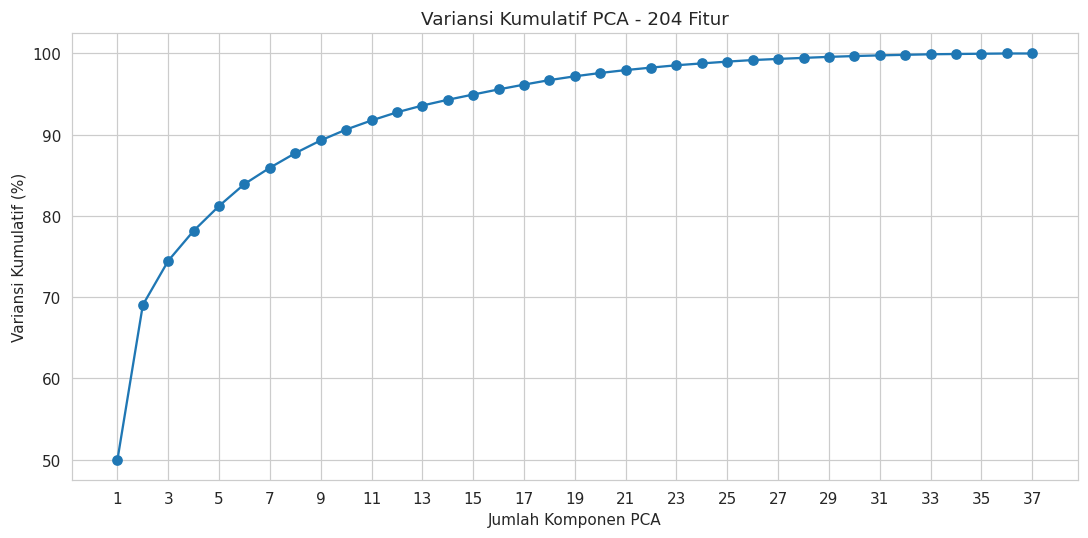

In [7]:
# GRAFIK VARIANSI PCA
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, 38),
    var_kumulatif,
    marker='o'
)

plt.xlabel('Jumlah Komponen PCA')
plt.ylabel('Variansi Kumulatif (%)')
plt.title(
    'Variansi Kumulatif PCA - 204 Fitur'
)

plt.xticks(range(1, 38, 2))
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f'{FIG}/pca_204_variansi.png'
)

plt.show()

## 6. Menentukan Jumlah Cluster

Dilakukan proses untuk menentukan jumlah cluster yang akan digunakan dalam K-Means.

Jumlah cluster yang diuji adalah:

K = 2 sampai K = 9.

Untuk setiap nilai K dilakukan proses K-Means pada data hasil PCA 37 komponen. Kemudian dihitung dua ukuran evaluasi, yaitu Inertia dan Silhouette Score.

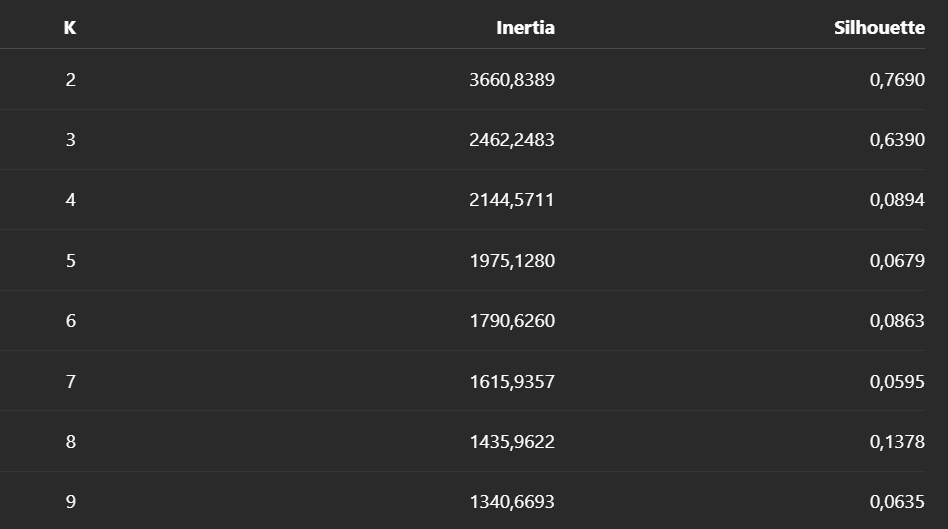

Inertia menunjukkan seberapa dekat anggota cluster terhadap pusat clusternya. Semakin kecil nilainya, semakin kecil jarak dalam cluster.

Sedangkan Silhouette Score digunakan untuk melihat seberapa baik pemisahan antarcluster. Nilai yang semakin mendekati 1 menunjukkan pemisahan cluster yang semakin jelas.

In [8]:
# MENENTUKAN JUMLAH CLUSTER
k_range = range(2, 10)

inertia_204 = []
silhouette_204 = []

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_pca_204
    )

    inertia_204.append(
        kmeans.inertia_
    )

    silhouette_204.append(
        silhouette_score(
            X_pca_204,
            labels
        )
    )


# 11. HASIL NILAI K
hasil_k = pd.DataFrame({
    'k': list(k_range),
    'inertia': inertia_204,
    'silhouette': silhouette_204
})

print(hasil_k.round(4))

   k    inertia  silhouette
0  2  3660.8389      0.7690
1  3  2462.2483      0.6390
2  4  2144.5711      0.0894
3  5  1975.1280      0.0679
4  6  1790.6260      0.0863
5  7  1615.9357      0.0595
6  8  1435.9622      0.1378
7  9  1340.6693      0.0635


## 7. Grafik Elbow dan Silhouette

Dibuat dua grafik untuk membantu melihat hasil pengujian jumlah cluster.

Grafik Elbow

Grafik Elbow menampilkan hubungan antara jumlah cluster dengan nilai inertia.

Ketika jumlah cluster bertambah, nilai inertia cenderung menurun. Grafik ini digunakan untuk mencari titik perubahan penurunan inertia yang cukup jelas.

Grafik Silhouette

Grafik kedua menunjukkan nilai Silhouette Score untuk setiap jumlah cluster.

Dari hasil pengujian, nilai Silhouette tertinggi diperoleh pada K = 2, yaitu sebesar 0,7690.

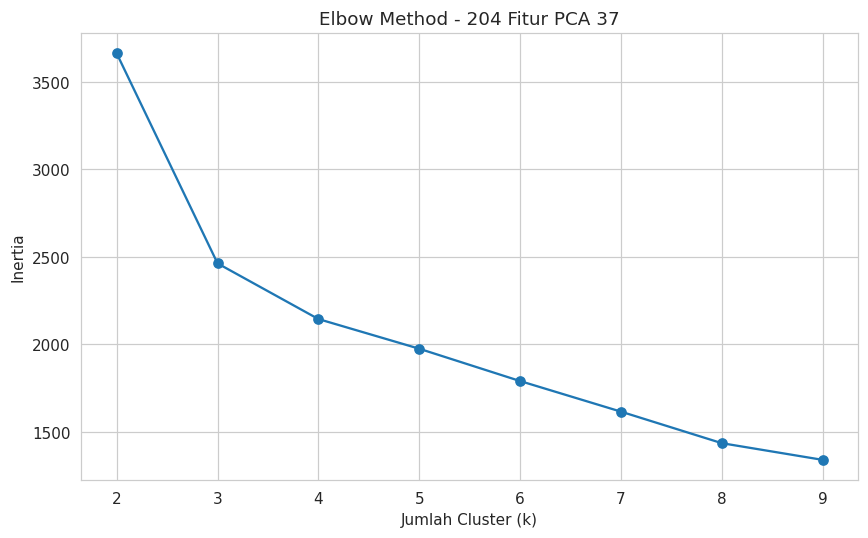

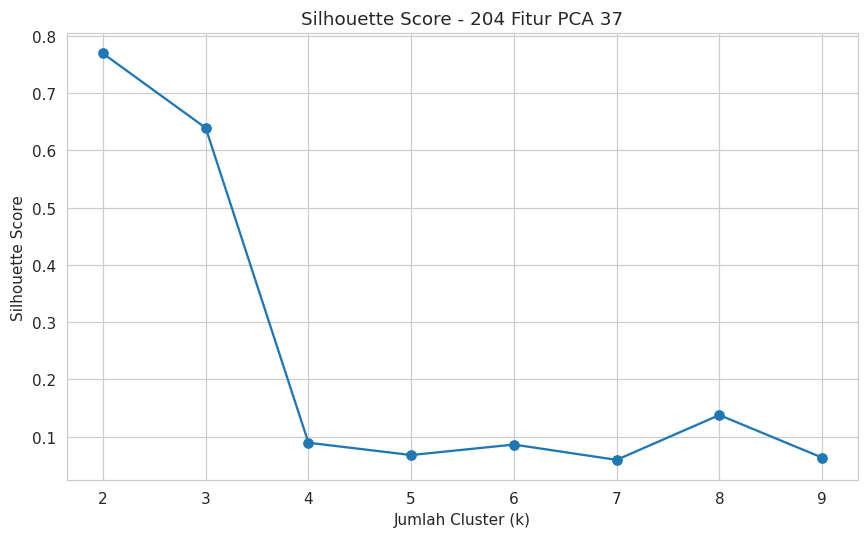

In [9]:
# GRAFIK ELBOW
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_range),
    inertia_204,
    marker='o'
)

plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title(
    'Elbow Method - 204 Fitur PCA 37'
)

plt.xticks(list(k_range))
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f'{FIG}/elbow_204.png'
)

plt.show()

# GRAFIK SILHOUETTE
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_range),
    silhouette_204,
    marker='o'
)

plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title(
    'Silhouette Score - 204 Fitur PCA 37'
)

plt.xticks(list(k_range))
plt.grid(True)

plt.tight_layout()

plt.savefig(
    f'{FIG}/silhouette_204.png'
)

plt.show()

## 8. Menentukan K Terbaik

Digunakan untuk memilih jumlah cluster berdasarkan nilai Silhouette Score tertinggi.

Hasil program menunjukkan:

K terbaik berdasarkan Silhouette = 2

dengan:

Silhouette Score = 0,7690

Artinya, berdasarkan kriteria Silhouette yang digunakan dalam notebook, konfigurasi dengan dua cluster menghasilkan nilai pemisahan cluster paling tinggi dibandingkan nilai K lainnya yang diuji.

In [10]:
# K TERBAIK
index_terbaik = np.argmax(
    silhouette_204
)

k_terbaik = list(k_range)[
    index_terbaik
]

sil_terbaik = silhouette_204[
    index_terbaik
]

print(
    f"K terbaik berdasarkan Silhouette = {k_terbaik}"
)

print(
    f"Silhouette Score = {sil_terbaik:.4f}"
)

K terbaik berdasarkan Silhouette = 2
Silhouette Score = 0.7690


## 9. K-Means Final

Setelah jumlah cluster ditentukan menjadi 2, dilakukan proses K-Means final menggunakan KMeans dengan:

* jumlah cluster = 2
* random_state = 42
* n_init = 10

Hasil cluster kemudian digabungkan dengan informasi identitas berupa id, nama, dan daerah.

Dari hasil pembagian cluster diperoleh:

* Cluster 1 = 36 data
* Cluster 2 = 1 data

Dengan demikian, 37 data terbagi ke dalam dua kelompok berdasarkan karakteristik 204 fitur polutan yang telah direduksi menggunakan PCA.

In [11]:
# K-MEANS FINAL
kmeans_final = KMeans(
    n_clusters=k_terbaik,
    random_state=42,
    n_init=10
)

cluster_final = kmeans_final.fit_predict(
    X_pca_204
)

hasil_cluster_204 = gabungan[
    id_cols
].copy()

hasil_cluster_204[
    'cluster'
] = cluster_final + 1

print(
    hasil_cluster_204.head()
)

print(
    "\nJumlah anggota masing-masing cluster:"
)

print(
    hasil_cluster_204[
        'cluster'
    ].value_counts().sort_index()
)

   id                             nama           daerah  cluster
0   2                Nurhabibatul Umah     Kerek, Tuban        1
1   3  Verdi Setyawan Ardiansyah Putra  Menganti Gresik        1
2   4          Okan Syailendra wahyudi   Manyar, Gresik        1
3   5          Mochammad Zaenal Abidin    Widang, Tuban        1
4   6              M. Hendrik Purwanto  Sreseh, Sampang        1

Jumlah anggota masing-masing cluster:
cluster
1    36
2     1
Name: count, dtype: int64


## 10. Visualisasi Hasil Clustering

Dilakukan visualisasi hasil K-Means menggunakan dua komponen utama, yaitu PCA 1 dan PCA 2.

PCA 1 digunakan sebagai sumbu X dan PCA 2 sebagai sumbu Y. Setiap titik menunjukkan satu data, sedangkan warna menunjukkan cluster yang dihasilkan oleh K-Means.

Visualisasi ini digunakan untuk melihat penyebaran data dan pemisahan antara cluster 1 dan cluster 2 secara visual.

Dengan menggunakan dua komponen utama, hasil clustering dapat ditampilkan dalam bentuk dua dimensi sehingga lebih mudah diamati.

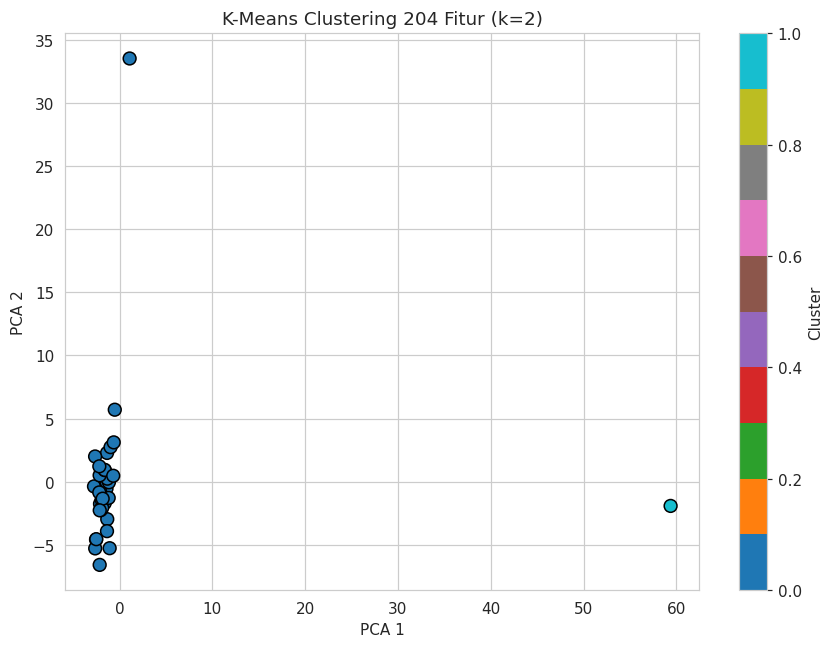

In [12]:
# VISUALISASI CLUSTER
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_204[:, 0],
    X_pca_204[:, 1],
    c=cluster_final,
    cmap='tab10',
    s=70,
    edgecolor='black'
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.title(
    f'K-Means Clustering 204 Fitur '
    f'(k={k_terbaik})'
)

plt.colorbar(
    label='Cluster'
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f'{FIG}/cluster_204.png'
)

plt.show()

## 11. Menyimpan Hasil Analisis

Digunakan untuk menyimpan hasil analisis ke dalam file CSV.

Terdapat dua file yang dihasilkan:

1. hasil_cluster_204fitur.csv
2. evaluasi_k_204fitur.csv

File hasil_cluster_204fitur.csv berisi informasi identitas data beserta cluster yang diperoleh dari K-Means.

Sedangkan evaluasi_k_204fitur.csv berisi hasil pengujian jumlah cluster dari K = 2 sampai K = 9, termasuk nilai inertia dan Silhouette Score.

Dengan menyimpan hasil tersebut ke dalam CSV, hasil analisis dapat digunakan kembali untuk proses berikutnya atau ditampilkan pada laporan.

In [13]:
# SIMPAN HASIL
hasil_cluster_204.to_csv(
    'hasil_cluster_204fitur.csv',
    index=False
)

hasil_k.to_csv(
    'evaluasi_k_204fitur.csv',
    index=False
)

print(
    "File berhasil disimpan:"
)

print(
    "- hasil_cluster_204fitur.csv"
)

print(
    "- evaluasi_k_204fitur.csv"
)

File berhasil disimpan:
- hasil_cluster_204fitur.csv
- evaluasi_k_204fitur.csv


# Implementasi Menggunakan KNIME

Pada notebook juga terdapat dokumentasi workflow menggunakan KNIME Analytics Platform. Workflow yang digunakan adalah:

CSV Reader → Column Filter → Normalizer → PCA → K-Means → Silhouette Coefficient

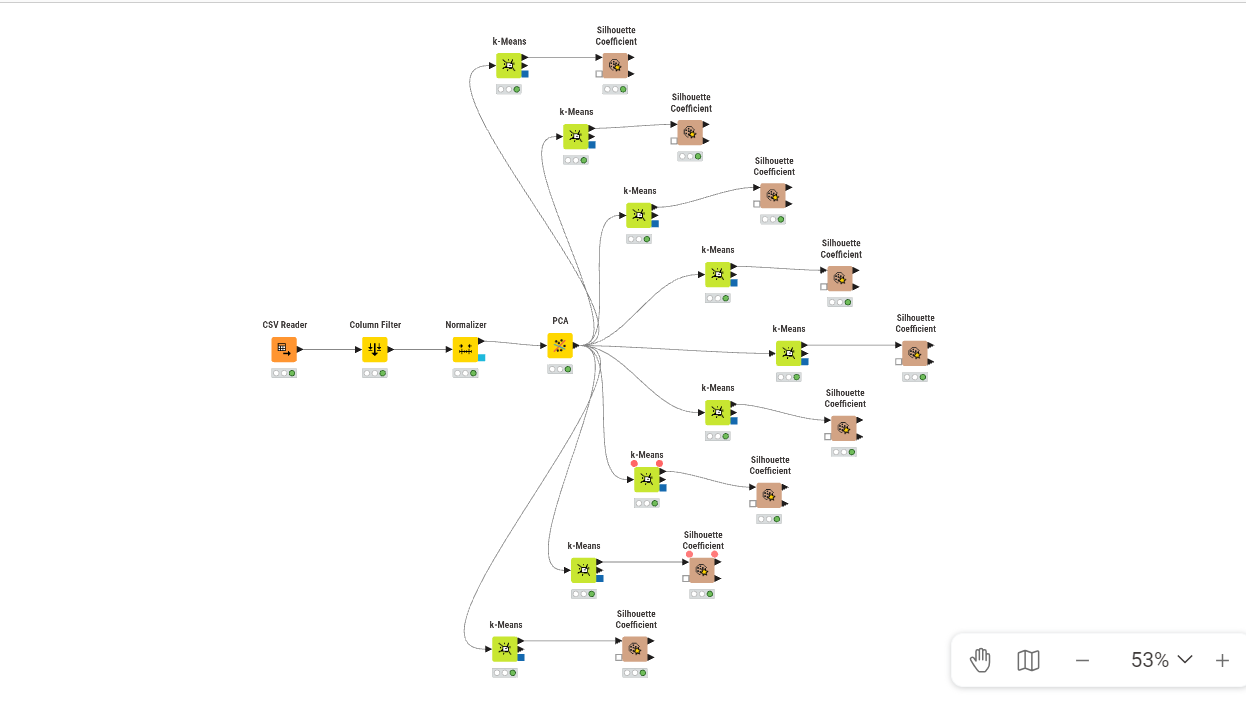

## 1. CSV Reader

CSV Reader digunakan untuk membaca data yang berasal dari file CSV.

Data yang dibaca berisi data hasil ekstraksi fitur yang akan digunakan dalam proses clustering.

Pada hasil KNIME terdapat 37 baris data. Kolom identitas seperti id, nama, dan daerah tetap digunakan untuk mengenali setiap data.

Fungsi utama:

Membaca dan memasukkan data CSV ke dalam workflow KNIME.

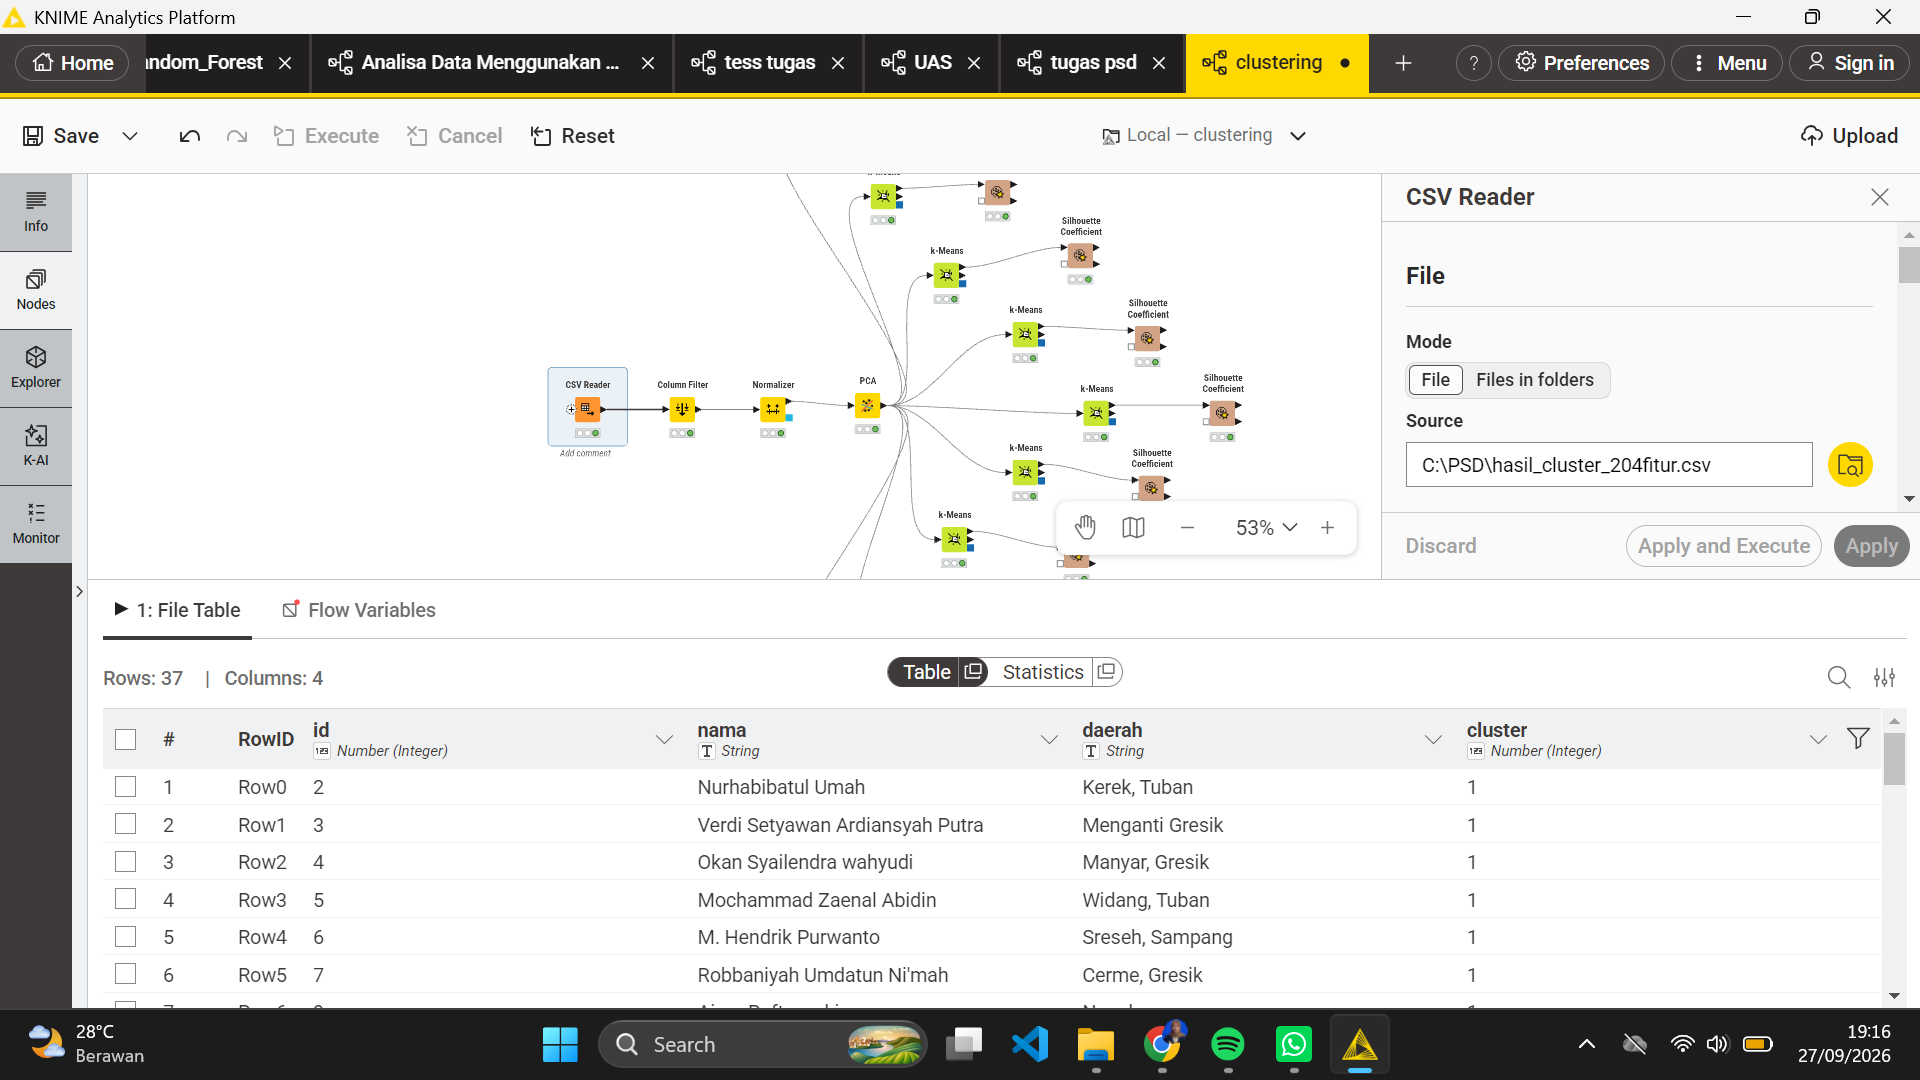

## 2. Pada workflow ini, node Column Filter digunakan untuk memisahkan kolom yang diperlukan dan tidak diperlukan sebelum data masuk ke proses normalisasi dan PCA.

Berdasarkan konfigurasi pada gambar:

* Excludes: Kolom nama dan daerah dikeluarkan karena tidak digunakan dalam proses perhitungan clustering.

* Includes: Kolom id dan cluster masih dimasukkan ke dalam tabel hasil penyaringan.

Hasil dari node Column Filter menunjukkan bahwa data memiliki 37 baris dan 2 kolom, yaitu id dan cluster. Data tersebut merupakan hasil penyaringan kolom sesuai konfigurasi yang ditampilkan.

Tujuan penggunaan Column Filter adalah menghilangkan kolom yang tidak diperlukan agar data lebih terstruktur dan memudahkan proses analisis selanjutnya.

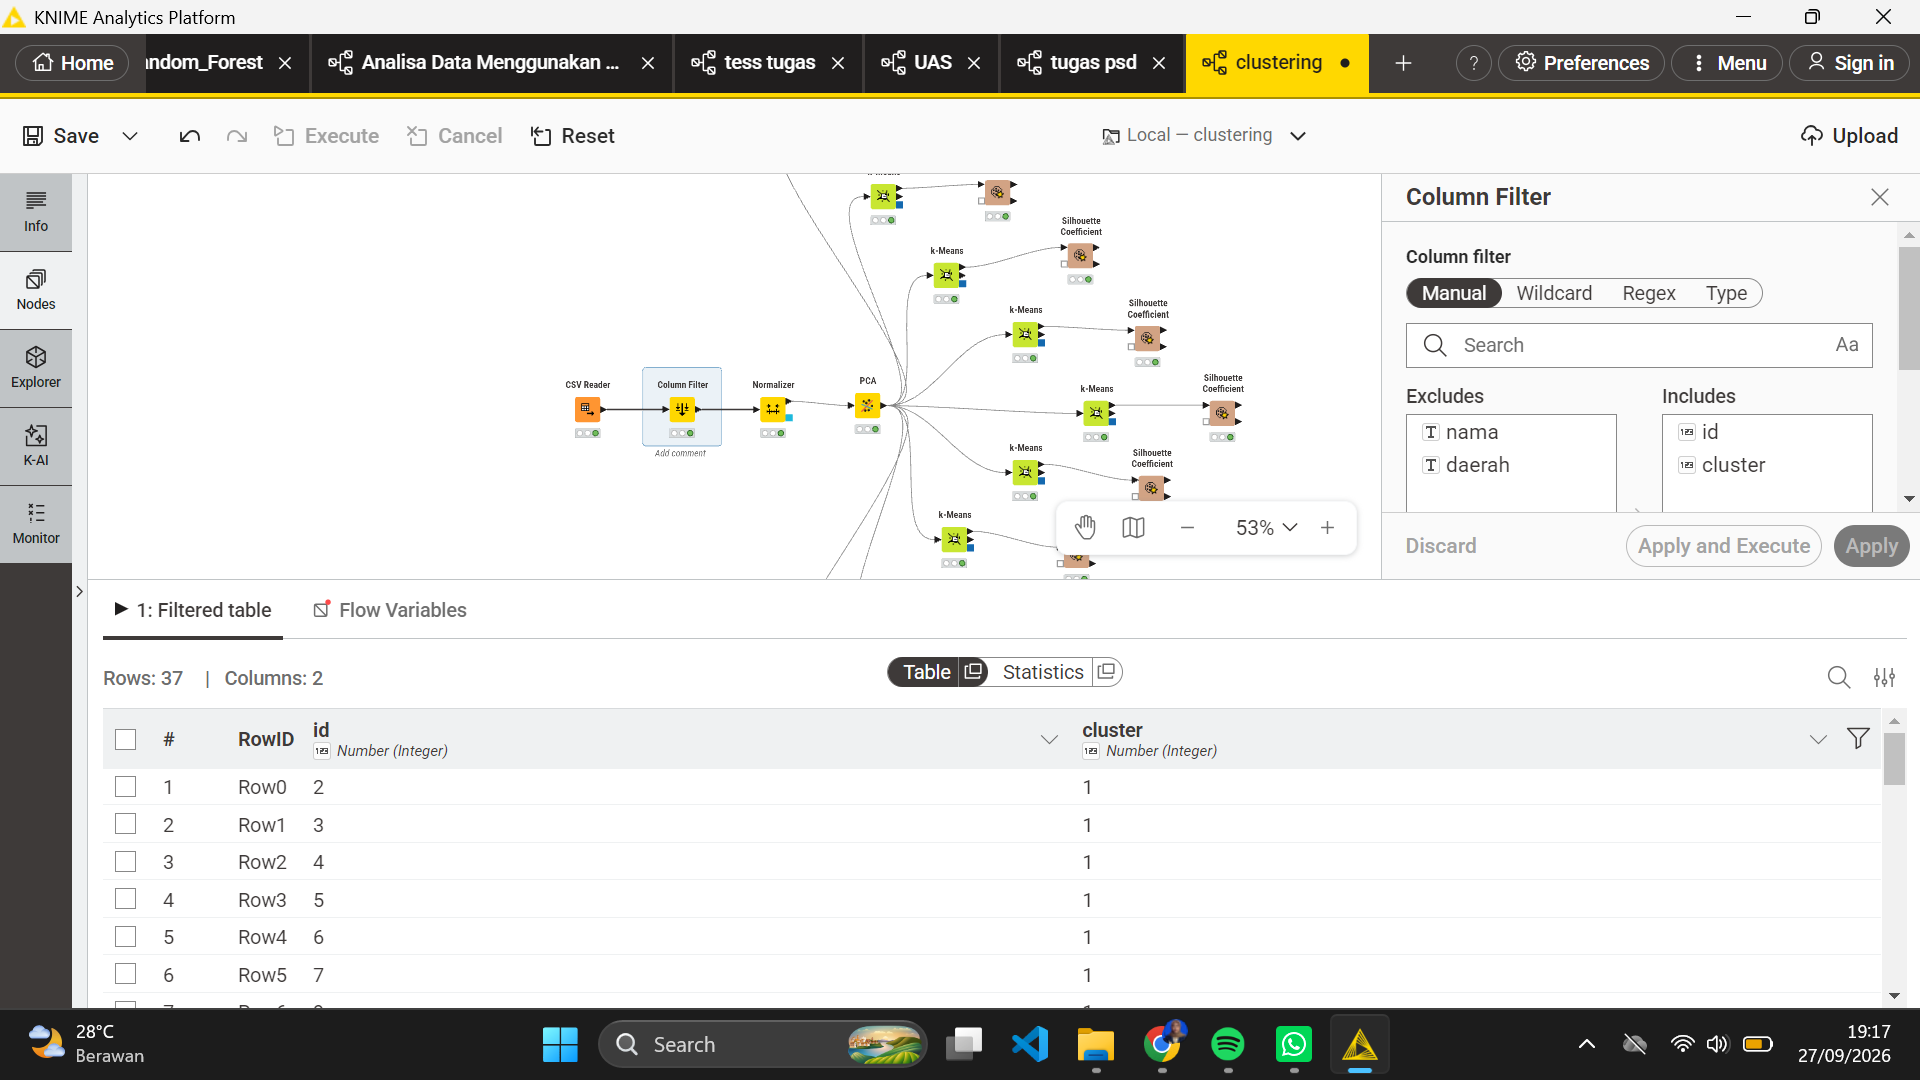

## 3. Normalizer

Node Normalizer digunakan untuk melakukan normalisasi atau penyamaan skala data numerik.

Hal ini penting karena setiap fitur dapat memiliki rentang nilai yang berbeda. Jika tidak dinormalisasi, fitur dengan nilai yang lebih besar dapat memberikan pengaruh yang lebih besar pada proses PCA dan K-Means.

Pada hasil KNIME terlihat adanya output Normalized table dan Normalize Model.

Fungsi utama:

Menyamakan skala nilai fitur sebelum dilakukan PCA dan clustering.

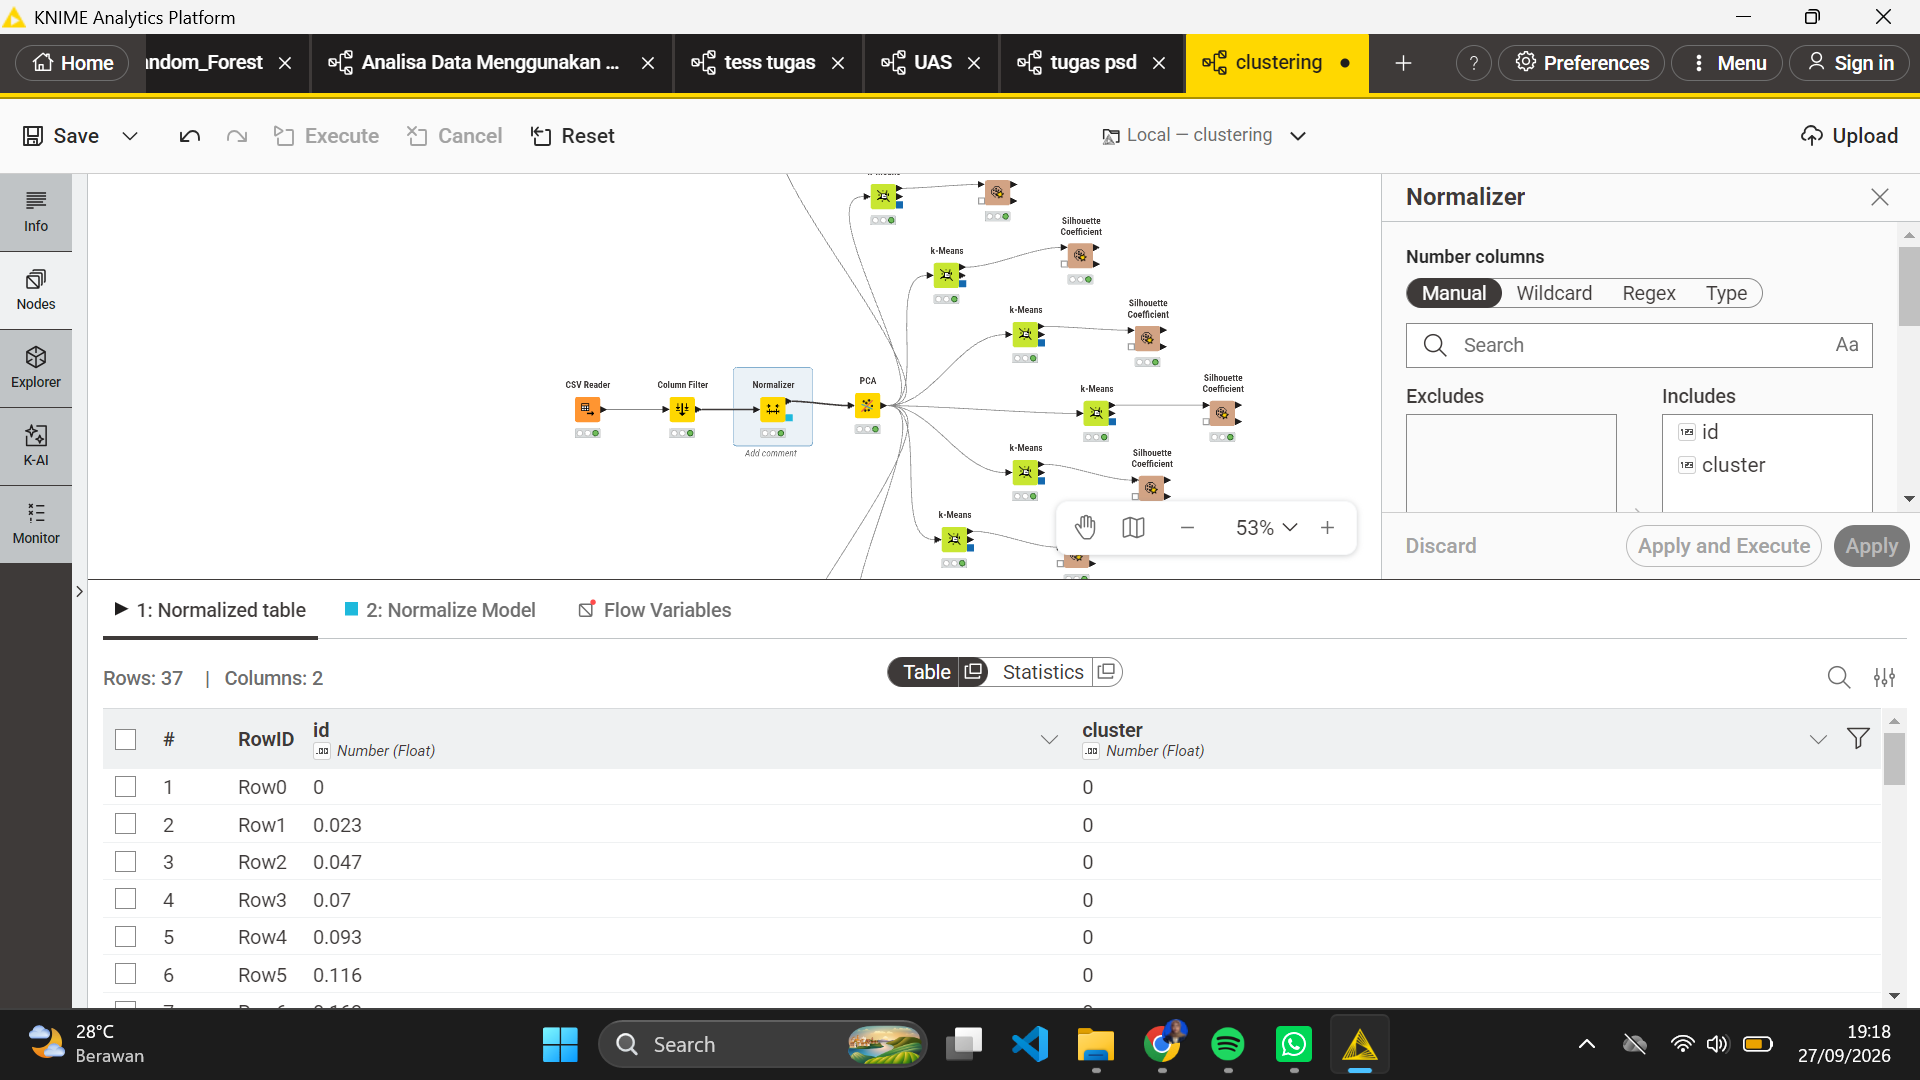

## 4. PCA

Node PCA (Principal Component Analysis) digunakan untuk melakukan reduksi dimensi.

Pada workflow, data yang sudah dinormalisasi diteruskan ke PCA. PCA mengubah sekumpulan fitur awal menjadi beberapa komponen utama.

Pada gambar konfigurasi PCA terdapat pilihan Target Dimensions, yaitu jumlah dimensi hasil reduksi.

Dalam tugas ini PCA digunakan untuk mereduksi data menjadi 37 dimensi.

Fungsi utama: Mengurangi jumlah fitur sambil mempertahankan informasi utama dari data.

Hasilnya berupa kolom seperti: PCA dimension 0, PCA dimension 1, dan seterusnya.

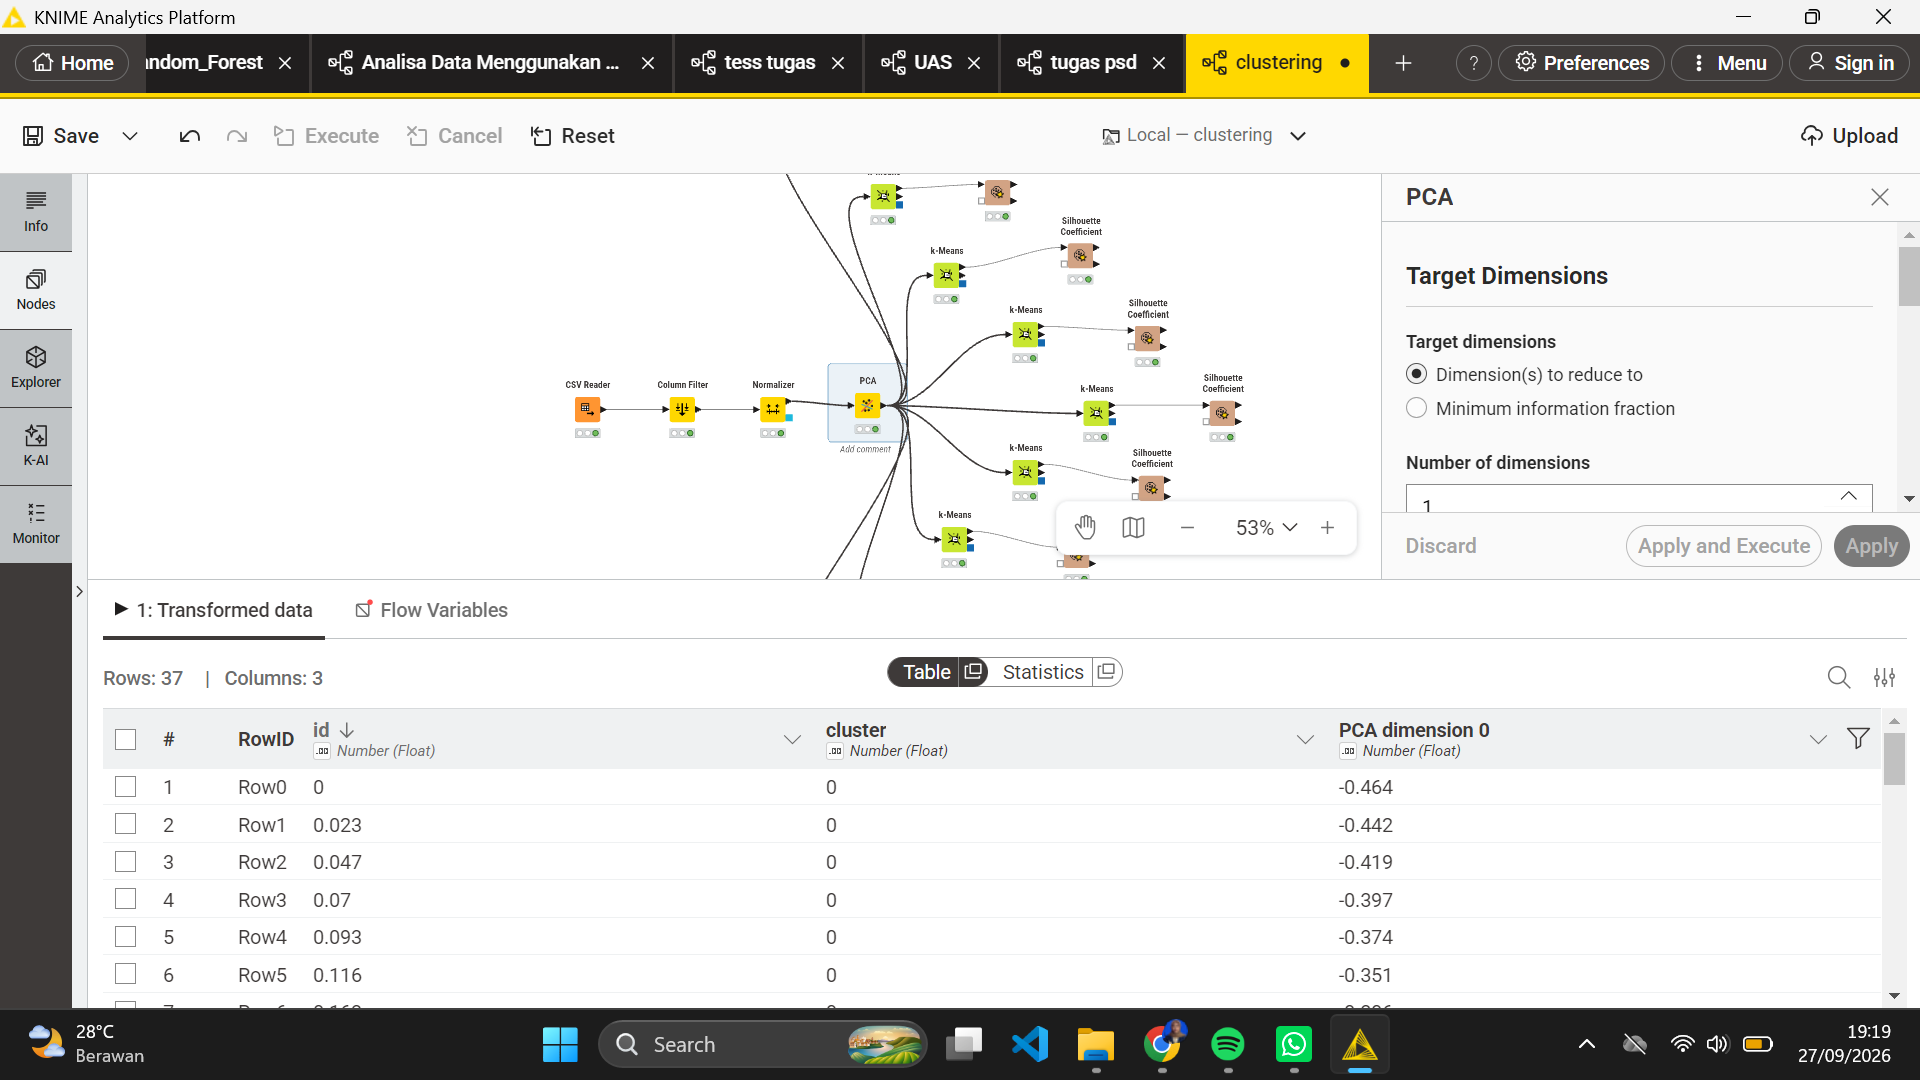

## 5. K-Means

Node K-Means digunakan untuk melakukan proses clustering.

K-Means mengelompokkan data berdasarkan kemiripan karakteristik. Algoritma ini bekerja dengan menentukan beberapa centroid kemudian mengelompokkan data ke centroid yang paling dekat.

Pada tugas ini jumlah cluster yang digunakan adalah 2 cluster berdasarkan hasil evaluasi sebelumnya.

Hasil node K-Means menghasilkan label cluster seperti:

cluster_0
cluster_1

Fungsi utama:

Mengelompokkan data menjadi beberapa kelompok berdasarkan kemiripan fitur PCA.

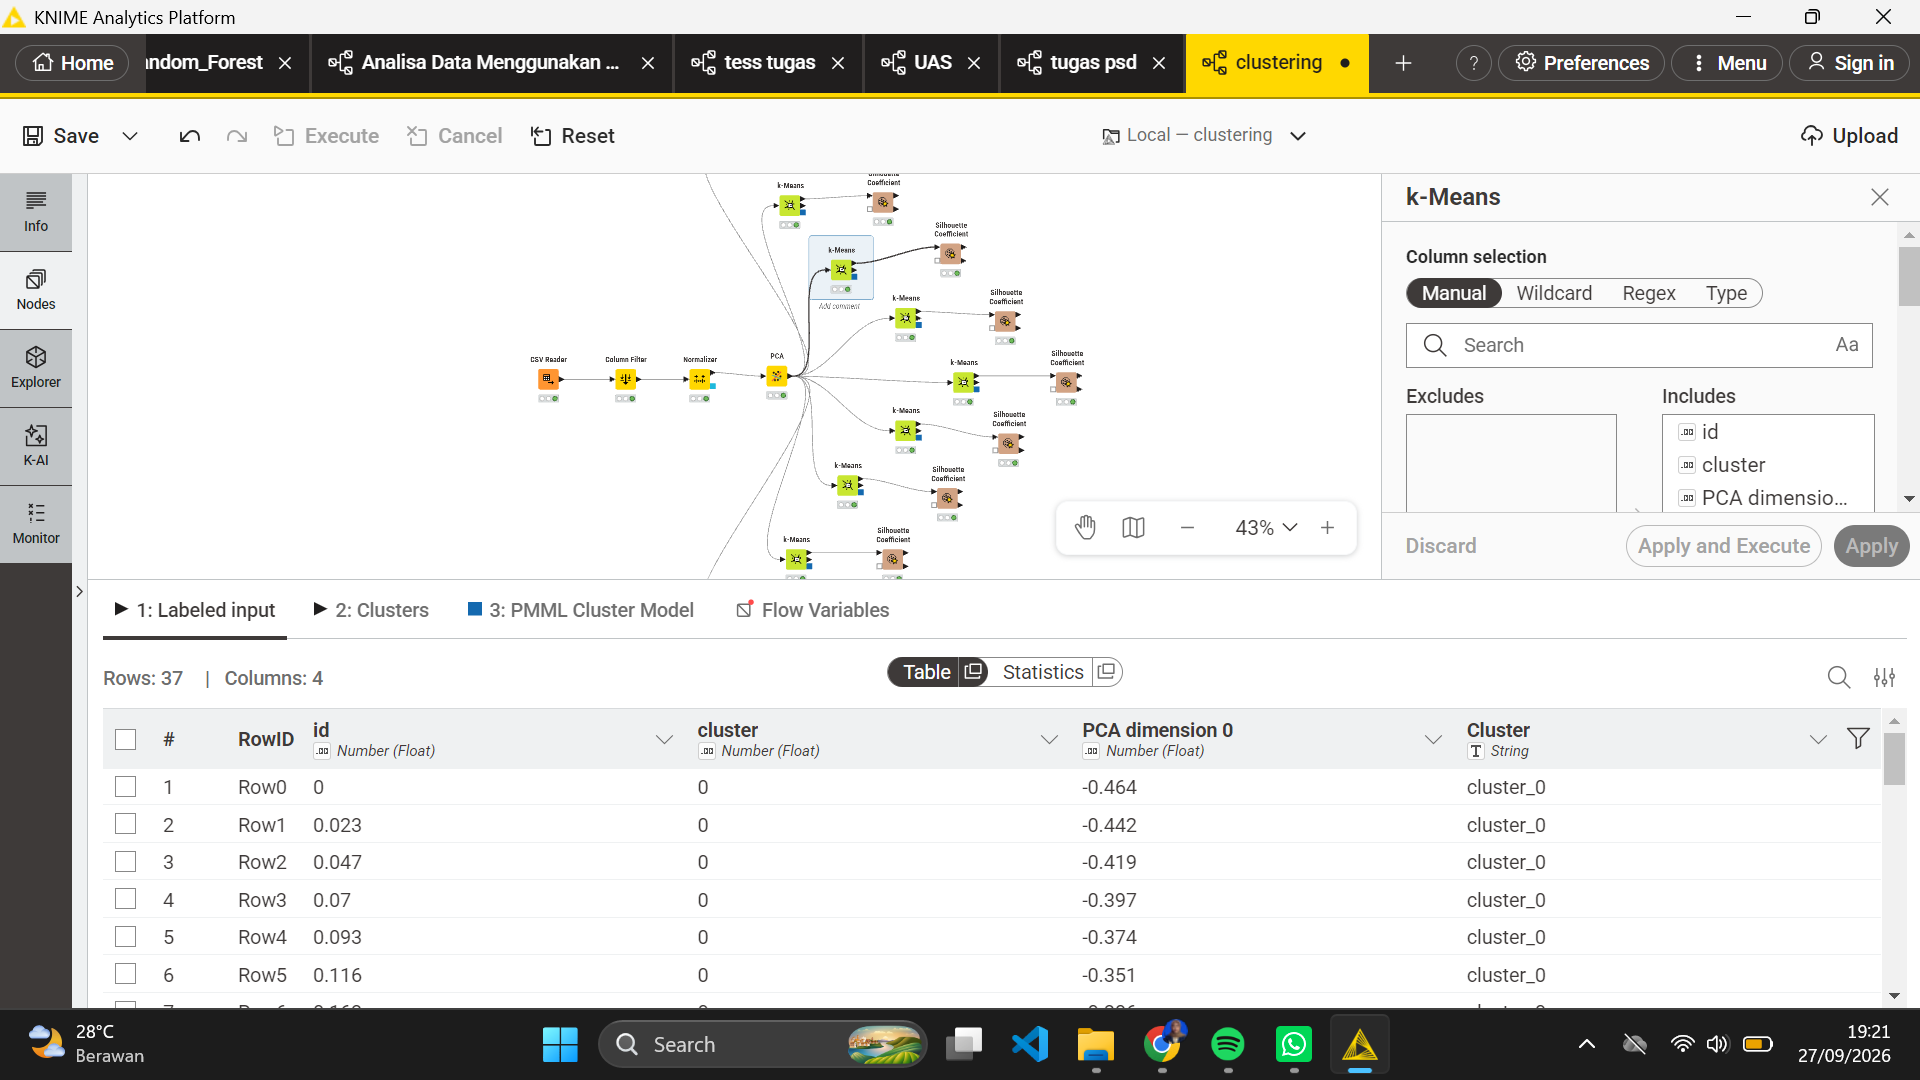

## 6. Silhouette Coefficient

Node Silhouette Coefficient digunakan untuk mengevaluasi kualitas hasil clustering.

Node ini menghasilkan nilai silhouette untuk data yang sudah memiliki label cluster.

Pada output KNIME terdapat kolom:

Silhouette Coefficient

Nilai ini digunakan untuk mengetahui seberapa baik data berada pada cluster yang terbentuk.

Selain tabel hasil, KNIME juga menampilkan Mean Silhouette Coefficient, yaitu nilai rata-rata silhouette dari seluruh data.

Fungsi utama:

Mengukur kualitas pemisahan antar-cluster yang dihasilkan K-Means.

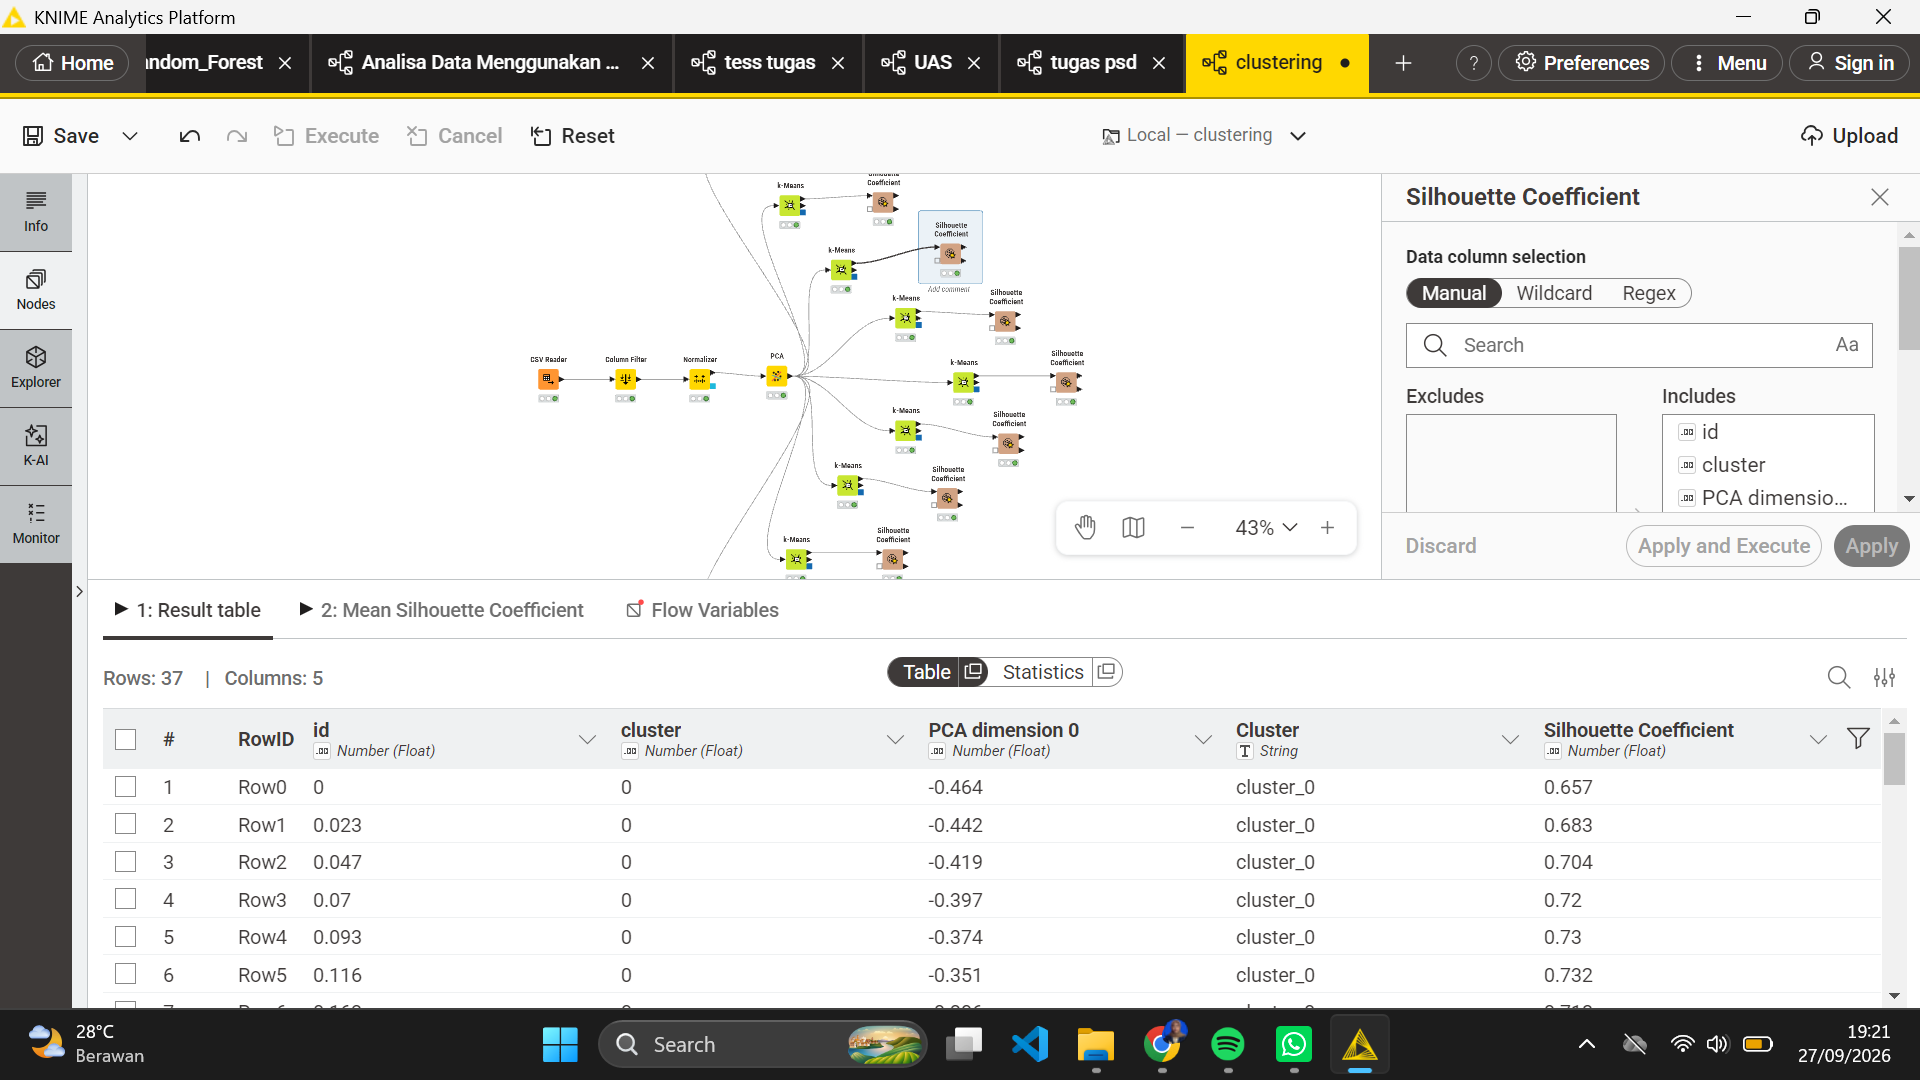

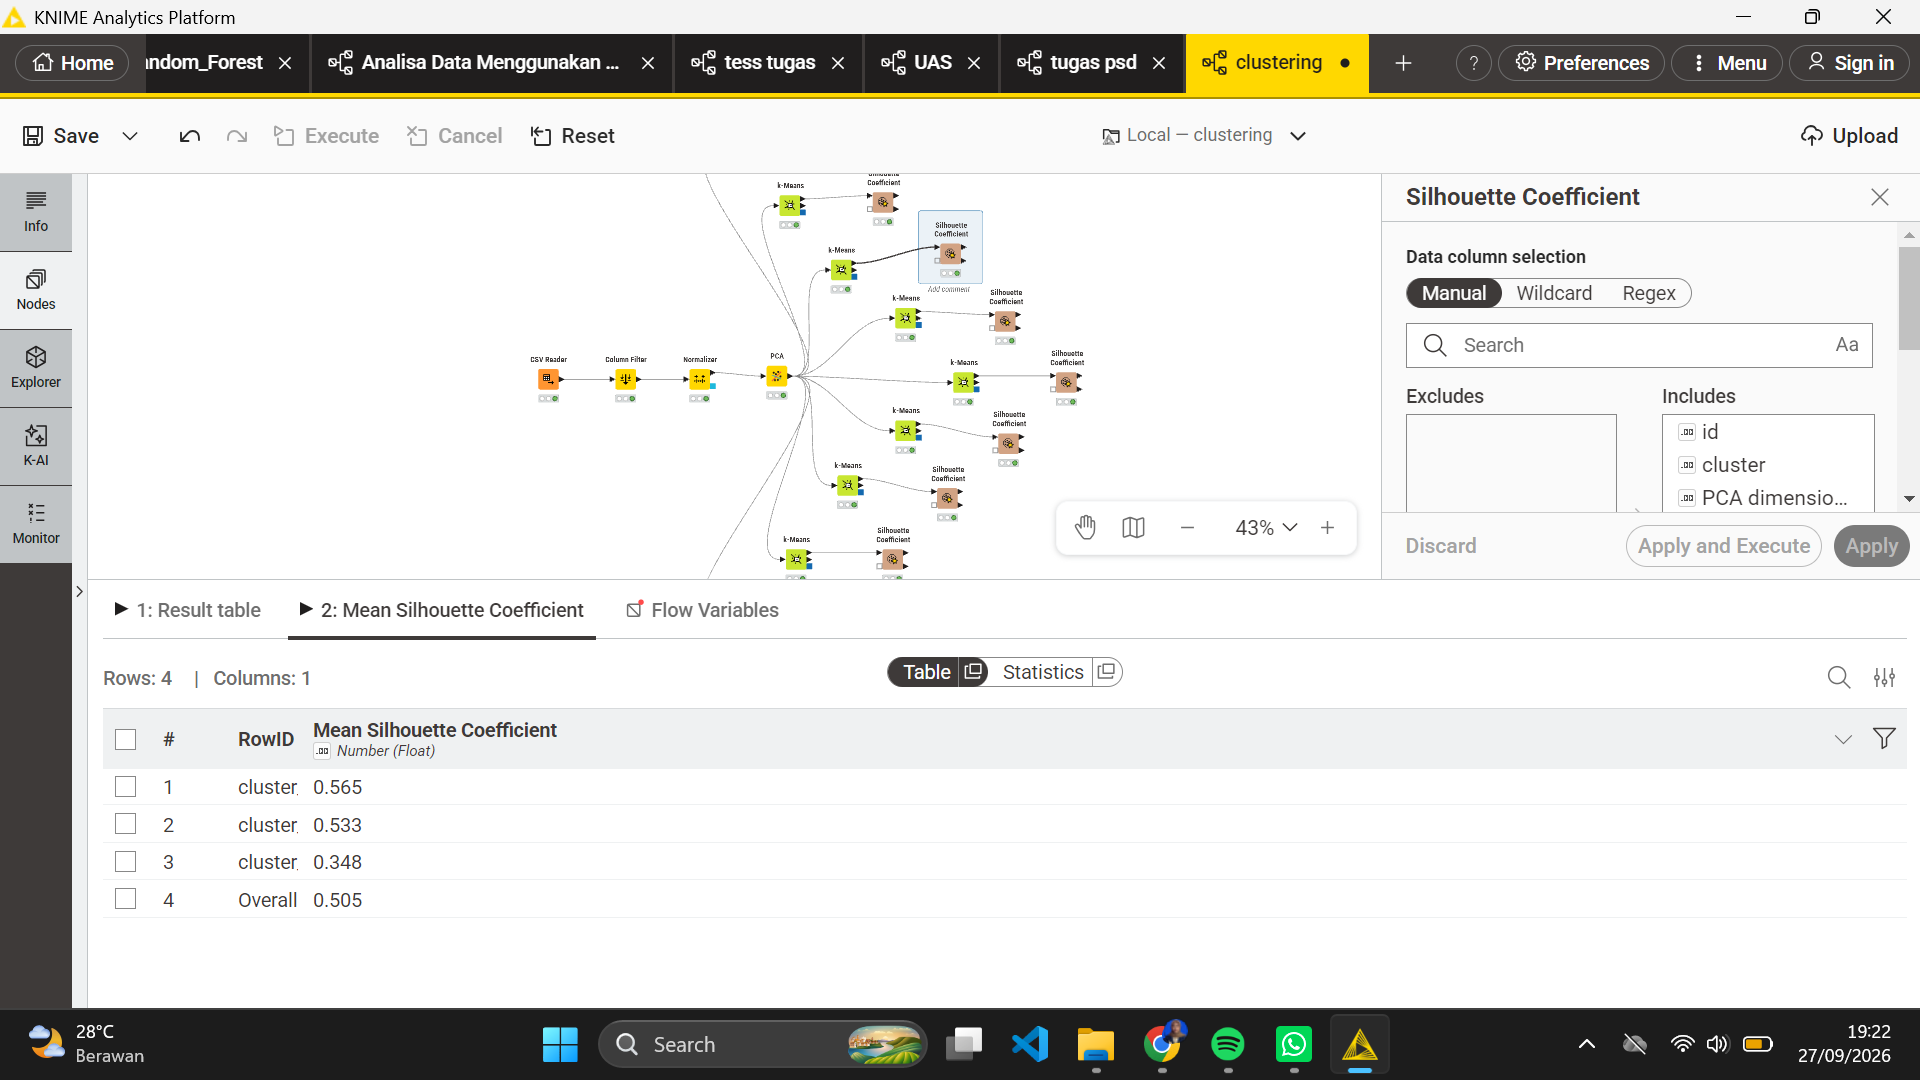

## Kesimpulan Analisis

Berdasarkan proses yang dilakukan pada Python dan KNIME, data yang terdiri dari 37 data dan 204 fitur hasil gabungan tiga polutan, yaitu SO₂, NO₂, dan CO, diproses melalui tahap preprocessing, standardisasi, reduksi dimensi menggunakan PCA, kemudian dikelompokkan menggunakan K-Means.

PCA digunakan untuk mengurangi jumlah fitur dari 204 menjadi 37 komponen sehingga data menjadi lebih sederhana untuk dianalisis. Selanjutnya dilakukan pengujian jumlah cluster dari k=2 sampai k=9 menggunakan inertia dan Silhouette Score. Berdasarkan hasil perhitungan pada notebook, konfigurasi 2 cluster pada PCA 37 menghasilkan Silhouette Score sekitar 0,7702.

Proses yang sama juga diterapkan menggunakan KNIME melalui rangkaian node CSV Reader → Normalizer → PCA → K-Means → Silhouette Coefficient. Dengan workflow tersebut, proses pembacaan data, normalisasi, reduksi dimensi, clustering, dan evaluasi kualitas cluster dapat dilakukan secara visual dan lebih mudah dipahami.